<a href="https://colab.research.google.com/github/matti410/Trading-System-Creator_V4/blob/main/Trading_System_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trading System Lab
### Dall'idea alla strategia verificata, in sette passi

Scegli tu i segnali di ingresso e le uscite. Lo strumento misura, scarta quello che non regge e ti dice quanto rischio aspettarti.

**Come si usa:** in ogni passo imposta i valori nel riquadro a destra, poi premi il tasto ▶ a sinistra della cella. I passi vanno eseguiti in ordine, dall'alto verso il basso.

## Avvio
Da eseguire una volta sola, all'inizio. Richiede circa un minuto.

In [1]:
#@title Avvio { display-mode: "form" }
import os, shutil, subprocess, sys, warnings
warnings.simplefilter("ignore")

REPO = "matti410/Trading-System-Creator_V4"
CARTELLA = "/content/Trading-System-Creator_V4"

subprocess.run([sys.executable, "-m", "pip", "install", "-q", "TA-Lib==0.8.1", "backtesting==0.6.6"], check=True)

# Il token di GitHub si legge dai Secrets di Colab (icona della chiave, a sinistra):
# non va mai scritto qui dentro. Senza token si prova il repo pubblico.
token = None
try:
    from google.colab import userdata
    token = userdata.get("GITHUB_TOKEN")
except Exception:
    pass

os.chdir("/content")
shutil.rmtree(CARTELLA, ignore_errors=True)
indirizzo = f"https://{token}@github.com/{REPO}.git" if token else f"https://github.com/{REPO}.git"
esito = subprocess.run(["git", "clone", "--quiet", "--depth", "1", indirizzo, CARTELLA], capture_output=True, text=True)
if esito.returncode != 0:
    raise RuntimeError("Non riesco a scaricare il progetto da GitHub. Se il repo è privato, controlla che il "
                       "secret GITHUB_TOKEN esista e che l'accesso dal notebook sia attivo.")

os.chdir(CARTELLA)
if CARTELLA not in sys.path:
    sys.path.insert(0, CARTELLA)
for nome in [m for m in sys.modules if m == "engine" or m.startswith("engine.")]:
    del sys.modules[nome]

%matplotlib inline
from IPython.utils.capture import capture_output
with capture_output():      # le librerie stampano avvisi tecnici al primo caricamento
    from engine.vetrina import (prepara, esplora, classifiche, scegli_trigger,
                                imposta_uscite, trova_strategia, scheda, stress_test)
print("Pronto.")

Pronto.


## 1 · Configura
Scegli lo strumento e per quante barre osservare il prezzo dopo ogni segnale (1 barra = 15 minuti).

In [2]:
#@title 1 · Configura { display-mode: "form" }
strumento = "BTCUSD"  #@param ["EURUSD", "BTCUSD"]
orizzonte = 25  #@param {type:"slider", min:4, max:96, step:1}

s = prepara(strumento, H=orizzonte)

,
Strumento,BTCUSD
Barre M15,221.512
Periodo,02/01/2020 – 19/09/2026
In-sample (per costruire),"177.209 barre, fino al 11/06/2025"
Out-of-sample (mai visto),"44.303 barre, dal 11/06/2025"
Costo per trade,"10,54 pips di spread, nessuna commissione (dati storici (75° percentile))"
Costo nel rollover,"11,61 pips"
Orizzonte di osservazione,"25 barre (6,2 ore)"
Trigger disponibili,28 long · 28 short
Filtri disponibili,34


## 2 · Esplora
Cosa fa il prezzo dopo ogni segnale di ingresso?

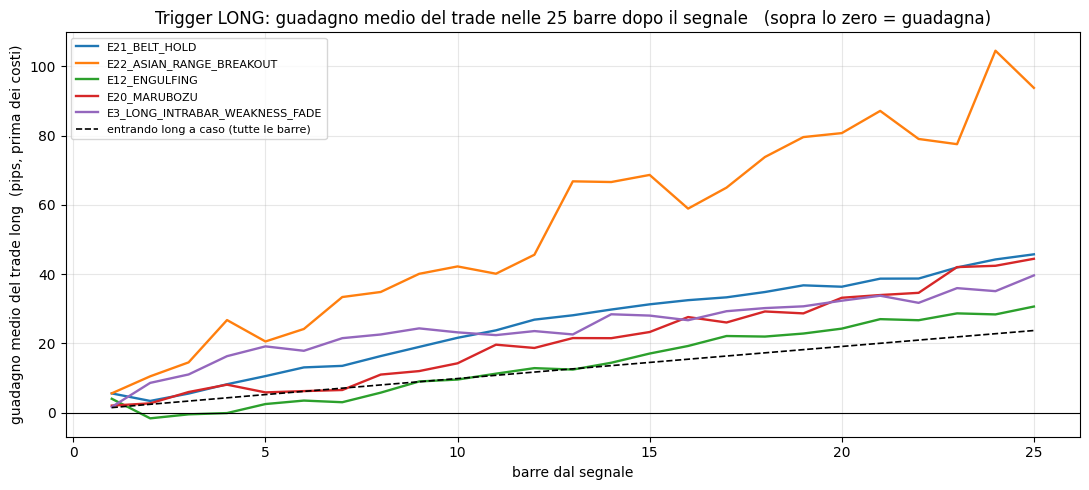

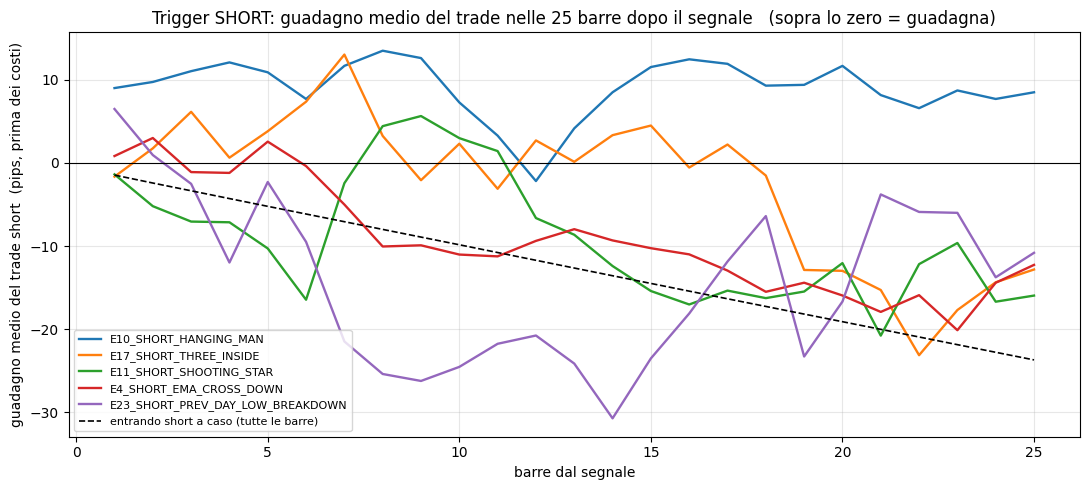

In [3]:
#@title 2 · Esplora { display-mode: "form" }
esplora(s);

## 3 · Scegli i trigger
Le due classifiche, e poi la tua scelta.

In [4]:
#@title 3a · Le classifiche { display-mode: "form" }
classifiche(s);

Trigger,Movimento a favore (pips),Dopo quante barre,Occasioni,Solidità del segnale,Supera il rumore
E21_BELT_HOLD,"45,18",25,12.166,"5,02",sì
E22_ASIAN_RANGE_BREAKOUT,"106,19",24,813,"3,62",no
E12_ENGULFING,"30,01",25,14.678,"3,54",no
E20_MARUBOZU,"44,79",25,3.744,"3,28",no
E3_LONG_INTRABAR_WEAKNESS_FADE,"39,81",25,7.757,"3,26",no
E21_BELT_HOLD_CONFIRMED,"35,51",25,5.813,"3,04",no
E8_CLOSING_PATTERN_ONLY,"32,10",25,7.270,"2,97",no
E2_ZLEMA_CROSS_UP,"27,57",25,10.794,"2,85",no
Trigger,Movimento a favore (pips),Dopo quante barre,Occasioni,Solidità del segnale,Supera il rumore
E10_SHORT_HANGING_MAN,"13,19",8,2.337,"1,55",no


In [5]:
#@title 3b · La tua scelta { display-mode: "form" }
#@markdown Copia i nomi dalla classifica. Più nomi sullo stesso lato: separali con una virgola. Lato vuoto = spento.
trigger_long = "E21_BELT_HOLD, E22_ASIAN_RANGE_BREAKOUT"  #@param {type:"string"}
trigger_short = ""  #@param {type:"string"}

scegli_trigger(s, long=trigger_long, short=trigger_short)

Lato,Trigger scelti
LONG,E21_BELT_HOLD oppure E22_ASIAN_RANGE_BREAKOUT
SHORT,nessuno (lato spento)


## 4 · Imposta le uscite
Dopo quante barre chiudere, e quanto larghi tenere stop e target.

Backtest.run:   0%|          | 0/177208 [00:00<?, ?bar/s]

Sistema,Trade,Guadagno medio netto per trade (pips),Trade vincenti (%),Solidità,Durata media (barre)
Solo long,4.721,"9,81","48,80","0,90","23,6"


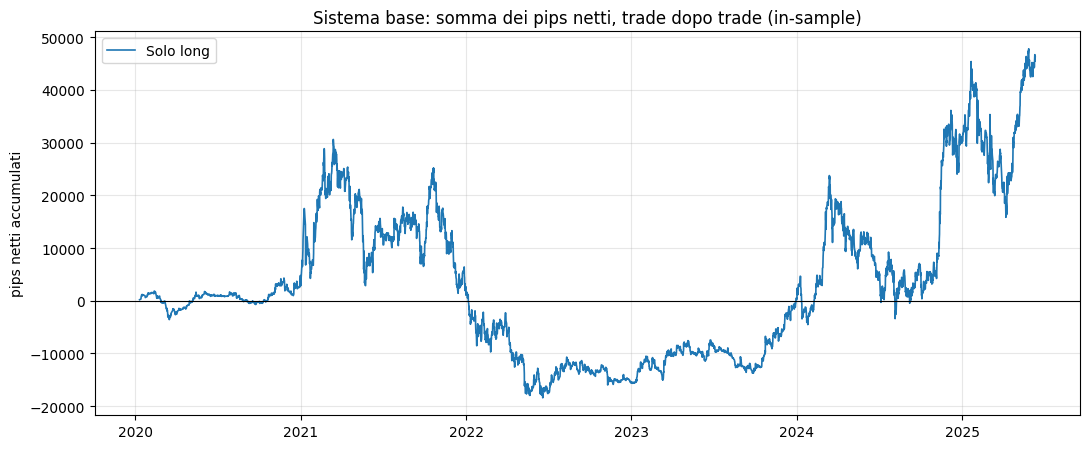

In [6]:
#@title 4 · Imposta le uscite { display-mode: "form" }
#@markdown Uscita a tempo, in barre (può essere diversa fra long e short)
barre_long = 25  #@param {type:"slider", min:1, max:96, step:1}
barre_short = 25  #@param {type:"slider", min:1, max:96, step:1}
#@markdown Stop e target adattivi, come percentile (0 = spento)
stop = 90  #@param {type:"slider", min:0, max:99, step:1}
target = 0  #@param {type:"slider", min:0, max:99, step:1}

imposta_uscite(s, barre_long=barre_long, barre_short=barre_short, sl=stop, tp=target);

## 5 · Trova la strategia
Lo strumento prova tutti i filtri disponibili sul tuo sistema base. Richiede circa mezzo minuto.

Backtest.run:   0%|          | 0/177208 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/177208 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/177208 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/177208 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/177208 [00:00<?, ?bar/s]

...

Backtest.run:   0%|          | 0/177208 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/177208 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/177208 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/177208 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/177208 [00:00<?, ?bar/s]

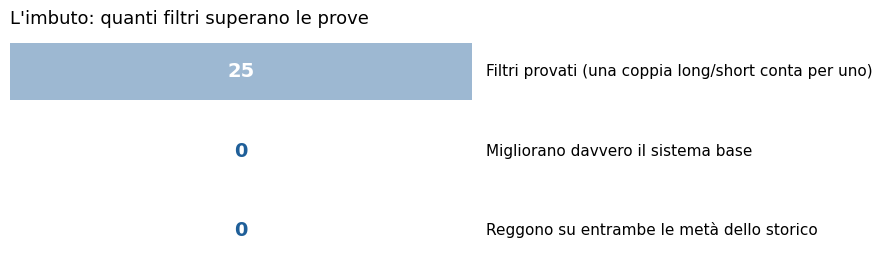

Filtro,Trade,Guadagno medio netto per trade (pips),Miglioramento sul sistema base (pips),Solidità del miglioramento,Prima prova,Seconda prova (due metà)
Sistema base (nessun filtro),4.721,"9,81",—,—,—,—
F3_VOLUME_ABOVE_AVG,3.355,"18,06","39,32","1,81",non passa,—
F6_VOLUME_ABOVE_AVG_50,3.181,"25,24","35,50","1,63",non passa,—
F8_UPTREND_CONTEXT,3.460,"16,48","29,82","1,33",non passa,—
F20_SESSION_US,1.630,"13,06","28,88","1,13",non passa,—
F10_TREND_CONVICTION_UP,1.982,"26,06","20,71","0,92",non passa,—
F14_LOW_DRIFT_REGIME,1.705,"15,98","20,71","0,90",non passa,—
F21_OVERNIGHT_UP,2.594,"12,75","17,93","0,82",non passa,—
F7_VOLUME_CLIMAX,1.309,"22,01","29,37","0,82",non passa,—


In [7]:
#@title 5 · Trova la strategia { display-mode: "form" }
trova_strategia(s);

## 6 · Scheda strategia
La prova sui dati che la strategia non ha mai visto.

In [13]:
#@title 6 · Scheda strategia { display-mode: "form" }
#@markdown Uno o più filtri copiati dalla classifica, separati da virgola: si entra solo quando sono veri tutti. Vuoto = sistema base, senza filtro.
filtro = "F3_VOLUME_ABOVE_AVG, F6_VOLUME_ABOVE_AVG_50"  #@param {type:"string"}

scheda(s, filtro=filtro);

ValueError: Filtro «F3_VOLUME_ABOVE_AVG, F6_VOLUME_ABOVE_AVG_50» non trovato. Copia il nome dalla classifica della schermata 5, oppure usa None per il sistema base.

## 7 · Stress test
Quanto drawdown aspettarsi, e con quanti lotti partire.

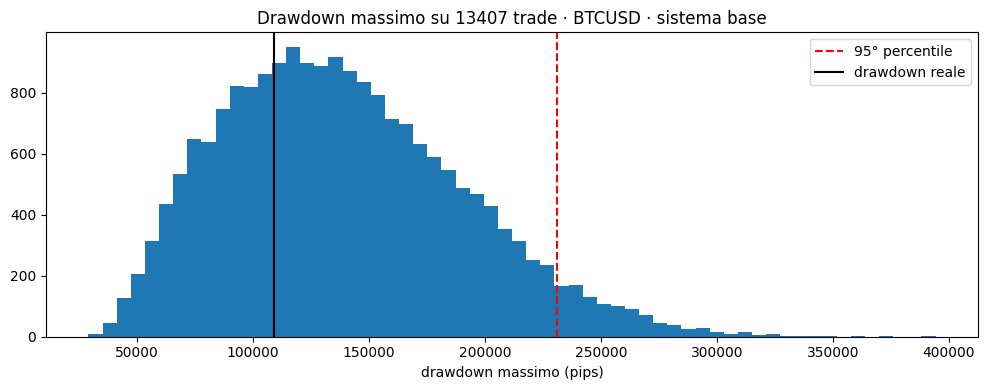

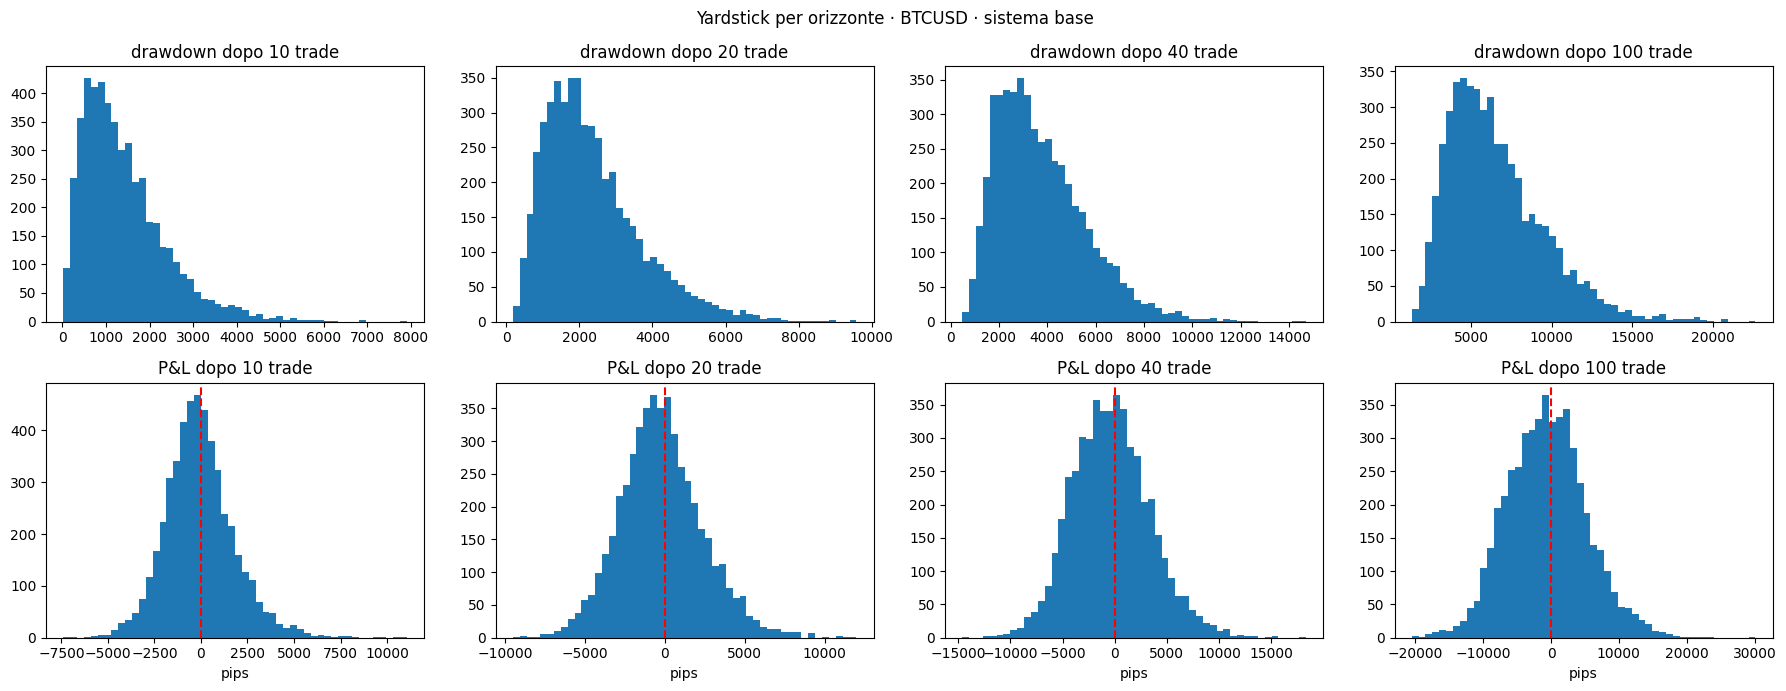

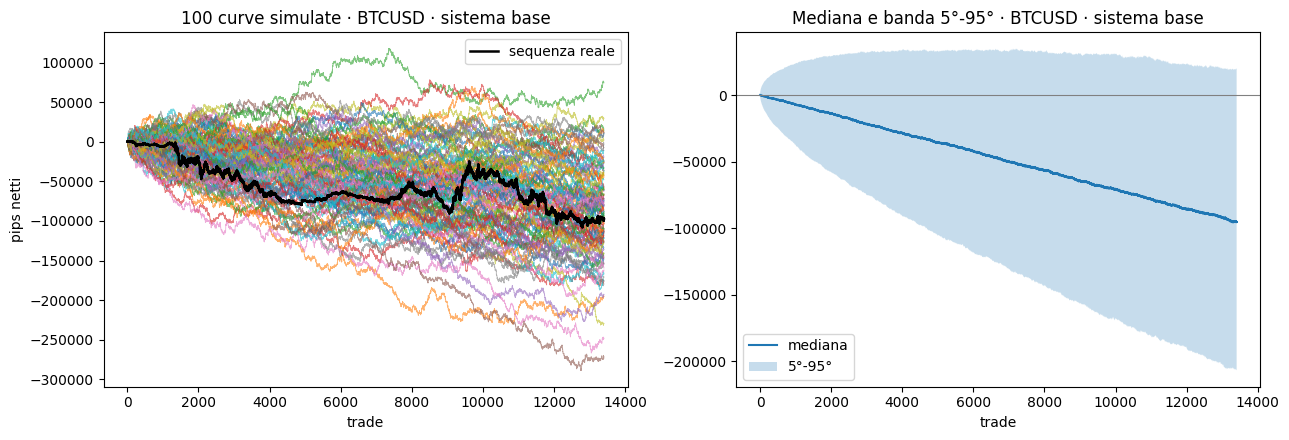

In [ ]:
#@title 7 · Stress test { display-mode: "form" }
drawdown_massimo_in_dollari = 10000  #@param {type:"number"}

stress_test(s, drawdown_max_usd=drawdown_massimo_in_dollari);